In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys

sys.path.append('../')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Bidirectional,
                                     LSTM, Dense, Dropout, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from scipy.sparse import issparse

print("TensorFlow:", tf.__version__)
print("All imports successful!")

TensorFlow: 2.21.0
All imports successful!


In [4]:
df = pd.read_csv('../data/cleaned_data.csv')
df = df.dropna(subset=['cleaned_text'])

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['label'],
    test_size=0.3,
    random_state=42
)

y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 50424
Test size : 21611


In [5]:
# TF-IDF vectorizer for the statistical branch
MAX_TFIDF = 10000  # keep top 10k features for this branch

tfidf_hybrid = TfidfVectorizer(
    max_features=MAX_TFIDF,
    ngram_range=(1, 2),
    sublinear_tf=True
)

# Fit on train only
X_train_tfidf = tfidf_hybrid.fit_transform(X_train)
X_test_tfidf  = tfidf_hybrid.transform(X_test)

# Convert sparse matrix to dense for Keras
X_train_tfidf_dense = X_train_tfidf.toarray().astype('float32')
X_test_tfidf_dense  = X_test_tfidf.toarray().astype('float32')

print("TF-IDF train shape:", X_train_tfidf_dense.shape)
print("TF-IDF test shape :", X_test_tfidf_dense.shape)

# Save hybrid tfidf vectorizer
with open('../models/tfidf_hybrid.pkl', 'wb') as f:
    pickle.dump(tfidf_hybrid, f)
print("Hybrid TF-IDF vectorizer saved!")


TF-IDF train shape: (50424, 10000)
TF-IDF test shape : (21611, 10000)
Hybrid TF-IDF vectorizer saved!


In [6]:
MAX_WORDS = 50000
MAX_LEN   = 300
EMBED_DIM = 128

# Tokenizer for BiLSTM branch
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print("Sequence train shape:", X_train_pad.shape)
print("Sequence test shape :", X_test_pad.shape)

# Save tokenizer
with open('../models/hybrid_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Hybrid tokenizer saved!")

Sequence train shape: (50424, 300)
Sequence test shape : (21611, 300)
Hybrid tokenizer saved!


In [7]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

def build_hybrid_model_v3(max_words, max_len, embed_dim, tfidf_dim):
    
    # --- Branch 1: BiLSTM ---
    seq_input = Input(shape=(max_len,), name='sequence_input')
    x1 = Embedding(input_dim=max_words,
                   output_dim=embed_dim,
                   input_length=max_len)(seq_input)
    
    # L2 regularization added to LSTM — penalizes large weights
    x1 = Bidirectional(LSTM(
        64,
        return_sequences=False,
        kernel_regularizer=l2(0.01),    # NEW
        recurrent_regularizer=l2(0.01)  # NEW
    ))(x1)
    x1 = Dropout(0.5)(x1)
    x1 = Dense(64, activation='relu',
                kernel_regularizer=l2(0.01))(x1)  # NEW

    # --- Branch 2: TF-IDF ---
    tfidf_input = Input(shape=(tfidf_dim,), name='tfidf_input')
    x2 = Dense(128, activation='relu',
                kernel_regularizer=l2(0.01))(tfidf_input)  # NEW
    x2 = Dropout(0.4)(x2)
    x2 = Dense(64, activation='relu',
                kernel_regularizer=l2(0.01))(x2)  # NEW

    # --- Merge ---
    merged = Concatenate()([x1, x2])
    x = Dense(64, activation='relu',
               kernel_regularizer=l2(0.01))(merged)  # NEW
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=[seq_input, tfidf_input], outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.0003),  # even slower learning
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

hybrid_model_v3 = build_hybrid_model_v3(
    MAX_WORDS, MAX_LEN, EMBED_DIM, MAX_TFIDF
)
hybrid_model_v3.summary()

c:\sem4_project\FakeNewsDetection\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  6,400,000 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf_input         │ (None, 10000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │  1,280,128 │ tfidf_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,803,777 (29.77 MB)

 Trainable params: 7,803,777 (29.77 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop_v3 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_v3 = ModelCheckpoint(
    '../models/hybrid_best_v3.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# NEW — automatically reduces learning rate when val_loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # halve the learning rate
    patience=2,        # after 2 epochs of no improvement
    min_lr=0.00001,
    verbose=1
)

print("Training Hybrid Model v3...")

history_v3 = hybrid_model_v3.fit(
    [X_train_pad, X_train_tfidf_dense],
    y_train_arr,
    epochs=15,
    batch_size=128,      # larger batch = more stable gradients
    validation_split=0.1,
    callbacks=[early_stop_v3, checkpoint_v3, reduce_lr],
    verbose=1
)

Training Hybrid Model v3...
Epoch 1/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.6830 - loss: 5.6481
Epoch 1: val_loss improved from None to 0.86966, saving model to ../models/hybrid_best_v3.keras

Epoch 1: finished saving model to ../models/hybrid_best_v3.keras
355/355 ━━━━━━━━━━━━━━━━━━━━ 235s 650ms/step - accuracy: 0.8220 - loss: 3.3726 - val_accuracy: 0.9510 - val_loss: 0.8697 - learning_rate: 3.0000e-04
Epoch 2/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.9665 - loss: 0.5989
Epoch 2: val_loss improved from 0.86966 to 0.26156, saving model to ../models/hybrid_best_v3.keras

Epoch 2: finished saving model to ../models/hybrid_best_v3.keras
355/355 ━━━━━━━━━━━━━━━━━━━━ 228s 643ms/step - accuracy: 0.9671 - loss: 0.4367 - val_accuracy: 0.9560 - val_loss: 0.2616 - learning_rate: 3.0000e-04
Epoch 3/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.9831 - loss: 0.1825
Epoch 3: val_loss improved from 0.26156 to 0.19515, saving model to ../models/hybri

In [9]:
y_pred_prob = hybrid_model_v3.predict([X_test_pad, X_test_tfidf_dense])
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

acc  = accuracy_score(y_test_arr, y_pred)
prec = precision_score(y_test_arr, y_pred)
rec  = recall_score(y_test_arr, y_pred)
f1   = f1_score(y_test_arr, y_pred)

print("="*45)
print("  Hybrid Model v3 Results")
print("="*45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")

676/676 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step
  Hybrid Model v3 Results
  Accuracy  : 0.9587
  Precision : 0.9559
  Recall    : 0.9645
  F1-Score  : 0.9602


In [10]:

"""

def build_hybrid_model(max_words, max_len, embed_dim, tfidf_dim):
    
    # --- Branch 1: BiLSTM (sequence input) ---
    seq_input = Input(shape=(max_len,), name='sequence_input')
    x1 = Embedding(input_dim=max_words,
                   output_dim=embed_dim,
                   input_length=max_len)(seq_input)
    x1 = Bidirectional(LSTM(128, return_sequences=False))(x1)
    x1 = Dropout(0.4)(x1)
    x1 = Dense(128, activation='relu')(x1)

    # --- Branch 2: TF-IDF (statistical input) ---
    tfidf_input = Input(shape=(tfidf_dim,), name='tfidf_input')
    x2 = Dense(256, activation='relu')(tfidf_input)
    x2 = Dropout(0.3)(x2)
    x2 = Dense(128, activation='relu')(x2)

    # --- Merge both branches ---
    merged = Concatenate()([x1, x2])
    x = Dense(128, activation='relu')(merged)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    output = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(
        inputs=[seq_input, tfidf_input],
        outputs=output
    )

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Build model
hybrid_model = build_hybrid_model(
    max_words=MAX_WORDS,
    max_len=MAX_LEN,
    embed_dim=EMBED_DIM,
    tfidf_dim=MAX_TFIDF
)

hybrid_model.summary()

"""

"\n\ndef build_hybrid_model(max_words, max_len, embed_dim, tfidf_dim):\n\n    # --- Branch 1: BiLSTM (sequence input) ---\n    seq_input = Input(shape=(max_len,), name='sequence_input')\n    x1 = Embedding(input_dim=max_words,\n                   output_dim=embed_dim,\n                   input_length=max_len)(seq_input)\n    x1 = Bidirectional(LSTM(128, return_sequences=False))(x1)\n    x1 = Dropout(0.4)(x1)\n    x1 = Dense(128, activation='relu')(x1)\n\n    # --- Branch 2: TF-IDF (statistical input) ---\n    tfidf_input = Input(shape=(tfidf_dim,), name='tfidf_input')\n    x2 = Dense(256, activation='relu')(tfidf_input)\n    x2 = Dropout(0.3)(x2)\n    x2 = Dense(128, activation='relu')(x2)\n\n    # --- Merge both branches ---\n    merged = Concatenate()([x1, x2])\n    x = Dense(128, activation='relu')(merged)\n    x = Dropout(0.4)(x)\n    x = Dense(64, activation='relu')(x)\n    output = Dense(1, activation='sigmoid', name='output')(x)\n\n    model = Model(\n        inputs=[seq_input, 

In [11]:
"""
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '../models/hybrid_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Training Hybrid Model...")
print("This will take 15-25 minutes on CPU\n")

history = hybrid_model.fit(
    [X_train_pad, X_train_tfidf_dense],  # two inputs
    y_train_arr,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nTraining complete!")


"""

'\nearly_stop = EarlyStopping(\n    monitor=\'val_loss\',\n    patience=15,\n    restore_best_weights=True\n)\n\ncheckpoint = ModelCheckpoint(\n    \'../models/hybrid_best.keras\',\n    monitor=\'val_accuracy\',\n    save_best_only=True,\n    verbose=1\n)\n\nprint("Training Hybrid Model...")\nprint("This will take 15-25 minutes on CPU\n")\n\nhistory = hybrid_model.fit(\n    [X_train_pad, X_train_tfidf_dense],  # two inputs\n    y_train_arr,\n    epochs=100,\n    batch_size=64,\n    validation_split=0.15,\n    callbacks=[early_stop, checkpoint],\n    verbose=1\n)\n\nprint("\nTraining complete!")\n\n\n'

In [12]:
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Hybrid Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Hybrid Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/hybrid_training_curves.png')
plt.show()
print("Training curves saved!")
"""

'\nfig, axes = plt.subplots(1, 2, figsize=(14, 5))\n\naxes[0].plot(history.history[\'accuracy\'],     label=\'Train Accuracy\')\naxes[0].plot(history.history[\'val_accuracy\'], label=\'Val Accuracy\')\naxes[0].set_title(\'Hybrid Model Accuracy\')\naxes[0].set_xlabel(\'Epoch\')\naxes[0].set_ylabel(\'Accuracy\')\naxes[0].legend()\n\naxes[1].plot(history.history[\'loss\'],     label=\'Train Loss\')\naxes[1].plot(history.history[\'val_loss\'], label=\'Val Loss\')\naxes[1].set_title(\'Hybrid Model Loss\')\naxes[1].set_xlabel(\'Epoch\')\naxes[1].set_ylabel(\'Loss\')\naxes[1].legend()\n\nplt.tight_layout()\nplt.savefig(\'../models/hybrid_training_curves.png\')\nplt.show()\nprint("Training curves saved!")\n'

In [13]:
"""
# Predict
y_pred_prob = hybrid_model.predict([X_test_pad, X_test_tfidf_dense])
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

acc  = accuracy_score(y_test_arr, y_pred)
prec = precision_score(y_test_arr, y_pred)
rec  = recall_score(y_test_arr, y_pred)
f1   = f1_score(y_test_arr, y_pred)

print("="*45)
print("  Hybrid Model (TF-IDF + BiLSTM) Results")
print("="*45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_arr, y_pred,
                            target_names=['Real', 'Fake']))

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix — Hybrid Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../models/Hybrid_confusion.png')
plt.show()

# Final comparison table
print("\n" + "="*60)
print("           FINAL MODEL COMPARISON TABLE")
print("="*60)
comparison = pd.DataFrame([
    {'Model': 'Naive Bayes',         'Accuracy': 0.8815,
     'Precision': 0.8751, 'Recall': 0.9019, 'F1': 0.8883},
    {'Model': 'Logistic Regression', 'Accuracy': 0.9643,
     'Precision': 0.9639, 'Recall': 0.9678, 'F1': 0.9659},
    {'Model': 'BiLSTM',              'Accuracy': 0.9681,
     'Precision': 0.9599, 'Recall': 0.9799, 'F1': 0.9698},
    {'Model': 'SVM',                 'Accuracy': 0.9766,
     'Precision': 0.9743, 'Recall': 0.9811, 'F1': 0.9777},
    {'Model': 'Hybrid (TF-IDF+BiLSTM)', 'Accuracy': round(acc, 4),
     'Precision': round(prec, 4), 'Recall': round(rec, 4),
     'F1': round(f1, 4)},
])
print(comparison.to_string(index=False))
comparison.to_csv('../models/final_comparison.csv', index=False)
print("\nFinal comparison saved → models/final_comparison.csv")
"""

'\n# Predict\ny_pred_prob = hybrid_model.predict([X_test_pad, X_test_tfidf_dense])\ny_pred      = (y_pred_prob > 0.5).astype(int).flatten()\n\nacc  = accuracy_score(y_test_arr, y_pred)\nprec = precision_score(y_test_arr, y_pred)\nrec  = recall_score(y_test_arr, y_pred)\nf1   = f1_score(y_test_arr, y_pred)\n\nprint("="*45)\nprint("  Hybrid Model (TF-IDF + BiLSTM) Results")\nprint("="*45)\nprint(f"  Accuracy  : {acc:.4f}")\nprint(f"  Precision : {prec:.4f}")\nprint(f"  Recall    : {rec:.4f}")\nprint(f"  F1-Score  : {f1:.4f}")\nprint("\nClassification Report:")\nprint(classification_report(y_test_arr, y_pred,\n                            target_names=[\'Real\', \'Fake\']))\n\n# Confusion Matrix\ncm = confusion_matrix(y_test_arr, y_pred)\nplt.figure(figsize=(5, 4))\nsns.heatmap(cm, annot=True, fmt=\'d\', cmap=\'Oranges\',\n            xticklabels=[\'Real\', \'Fake\'],\n            yticklabels=[\'Real\', \'Fake\'])\nplt.title(\'Confusion Matrix — Hybrid Model\')\nplt.ylabel(\'Actual\')\nplt

In [14]:
"""
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Model
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=5000, output_dim=128))

# BiLSTM layer
model.add(Bidirectional(LSTM(64)))

# 🔥 Dropout added (reduces overfitting)
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 🔥 Early stopping added
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=6,  # 🔥 reduced epochs
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)
"""

"\nimport tensorflow as tf\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout\nfrom tensorflow.keras.callbacks import EarlyStopping\n\n# Model\nmodel = Sequential()\n\n# Embedding layer\nmodel.add(Embedding(input_dim=5000, output_dim=128))\n\n# BiLSTM layer\nmodel.add(Bidirectional(LSTM(64)))\n\n# 🔥 Dropout added (reduces overfitting)\nmodel.add(Dropout(0.5))\n\n# Output layer\nmodel.add(Dense(1, activation='sigmoid'))\n\n# Compile\nmodel.compile(\n    loss='binary_crossentropy',\n    optimizer='adam',\n    metrics=['accuracy']\n)\n\n# 🔥 Early stopping added\nearly_stop = EarlyStopping(\n    monitor='val_loss',\n    patience=2,\n    restore_best_weights=True\n)\n\n# Train\nhistory = model.fit(\n    X_train,\n    y_train,\n    epochs=6,  # 🔥 reduced epochs\n    batch_size=64,\n    validation_data=(X_val, y_val),\n    callbacks=[early_stop]\n)\n"

676/676 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step
  Hybrid Model v3 Results
  Accuracy  : 0.9587
  Precision : 0.9559
  Recall    : 0.9645
  F1-Score  : 0.9602

Classification Report:
              precision    recall  f1-score   support

        Real       0.96      0.95      0.96     10445
        Fake       0.96      0.96      0.96     11166

    accuracy                           0.96     21611
   macro avg       0.96      0.96      0.96     21611
weighted avg       0.96      0.96      0.96     21611



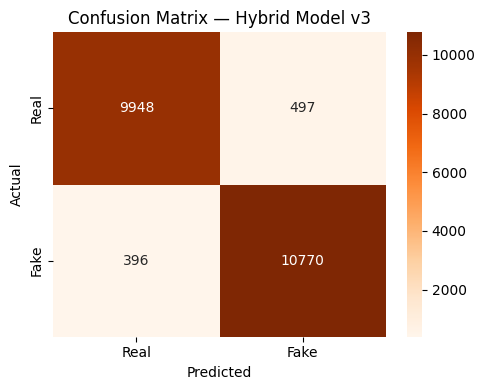

In [15]:
# Predict
y_pred_prob = hybrid_model_v3.predict([X_test_pad, X_test_tfidf_dense])
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

acc  = accuracy_score(y_test_arr, y_pred)
prec = precision_score(y_test_arr, y_pred)
rec  = recall_score(y_test_arr, y_pred)
f1   = f1_score(y_test_arr, y_pred)

print("="*45)
print("  Hybrid Model v3 Results")
print("="*45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_arr,
    y_pred,
    target_names=['Real', 'Fake']
))

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

plt.title('Confusion Matrix — Hybrid Model v3')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

plt.savefig('../models/Hybrid_v3_confusion.png')
plt.show()

In [16]:
import pandas as pd
import os

csv_path = "../models/final_comparison.csv"

# Load existing comparison table
if os.path.exists(csv_path):
    comparison = pd.read_csv(csv_path)
else:
    comparison = pd.DataFrame()

# Remove old v3 row if it already exists
comparison = comparison[
    comparison["Model"] != "Hybrid Model v3"
]

# Add new row
new_row = pd.DataFrame([{
    "Model": "Hybrid Model v3",
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1": round(f1, 4)
}])

comparison = pd.concat(
    [comparison, new_row],
    ignore_index=True
)

print("\n" + "="*60)
print("           FINAL MODEL COMPARISON TABLE")
print("="*60)

print(comparison.to_string(index=False))

# Save back
comparison.to_csv(csv_path, index=False)

print(f"\nUpdated comparison saved → {csv_path}")


           FINAL MODEL COMPARISON TABLE
                 Model  Accuracy  Precision  Recall     F1
           Naive Bayes    0.8815     0.8751  0.9019 0.8883
   Logistic Regression    0.9643     0.9639  0.9678 0.9659
                BiLSTM    0.9681     0.9599  0.9799 0.9698
                   SVM    0.9766     0.9743  0.9811 0.9777
Hybrid (TF-IDF+BiLSTM)    0.9745     0.9581  0.9943 0.9758
       Hybrid Model v3    0.9587     0.9559  0.9645 0.9602

Updated comparison saved → ../models/final_comparison.csv


In [17]:
print(type(hybrid_model_v3))

<class 'keras.src.models.functional.Functional'>


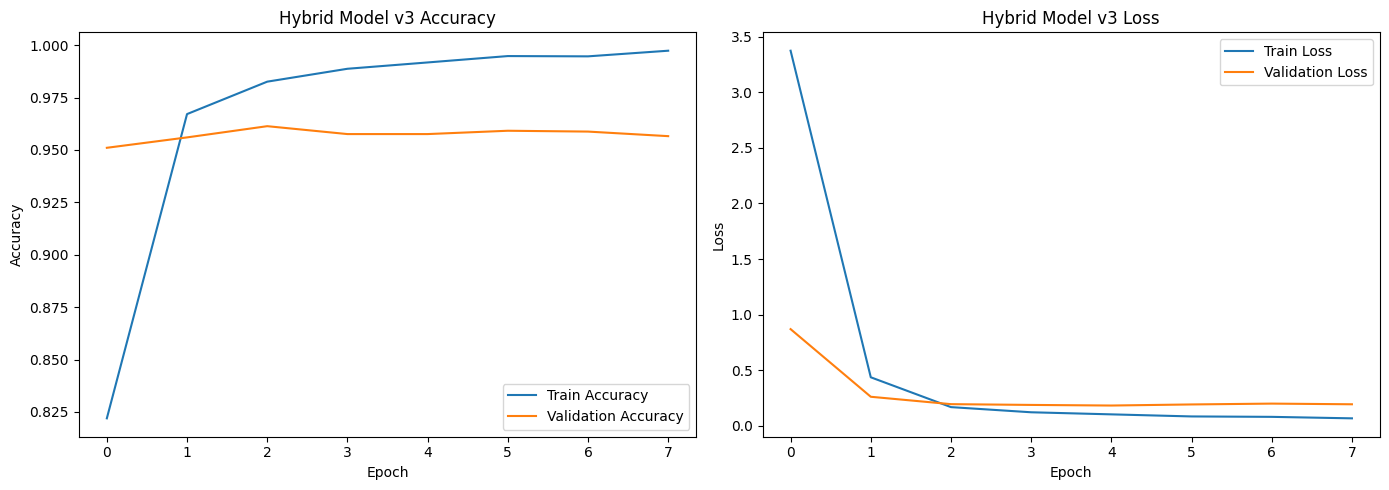

Best Validation Accuracy: 0.9613


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_v3.history['accuracy'],
             label='Train Accuracy')
axes[0].plot(history_v3.history['val_accuracy'],
             label='Validation Accuracy')

axes[0].set_title('Hybrid Model v3 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_v3.history['loss'],
             label='Train Loss')
axes[1].plot(history_v3.history['val_loss'],
             label='Validation Loss')

axes[1].set_title('Hybrid Model v3 Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()

# Save figure
plt.savefig('../models/hybrid_v3_training_curves.png',
            bbox_inches='tight')

plt.show()

print(
    f"Best Validation Accuracy: "
    f"{max(history_v3.history['val_accuracy']):.4f}"
)